# AI Incident Response Playbook: SunExpress 737 Gear Collapse at Antalya

## What Happened

On 13 February 2026, a SunExpress Boeing 737-800 (registration TC-SOB, flight XQ7646) suffered a left main landing gear collapse while taxiing for departure at Antalya Airport in Turkey. The aircraft ended up resting on one of its engines on the taxiway. All 156 passengers and crew were safely evacuated via stairs with no injuries reported [1]. The taxiway was blocked for roughly 4.5 hours until a replacement aircraft (TC-SOP) could be arranged [2].

SunExpress described the event as "a technical issue involving the landing-gear strut" [1]. The root cause has not yet been determined, and the aircraft remains grounded for inspection and likely significant repairs.

This kind of incident, while rare, puts enormous pressure on airline operations teams. Within minutes of the gear collapse, multiple things need to happen at once: secure the area, communicate with air traffic control, deplane passengers safely, rebook passengers onto alternative flights, notify regulators, and begin preserving evidence for investigation. Missing or delaying any of these steps can lead to safety risks, regulatory penalties, or reputational damage. In this notebook, we build a local AI agent that can assist operations teams during these high-stress situations by walking through incident response procedures step-by-step.

## Environment Setup

This demo runs on a Mac with M-series chip and 8 GB of memory. We use a local LLM via Ollama so nothing leaves your machine.

**Prerequisite:**
Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install) and [Ollama](https://ollama.com/).

**Terminal commands to create the environment:**
```bash
# Create and activate the conda environment
conda create -n incident-mgmt python=3.10 -y
conda activate incident-mgmt

# Install core libraries
conda install -c conda-forge numpy pandas matplotlib seaborn jupyter jupyterlab ipython pillow ipykernel -y

# Install LangChain, Ollama bindings, and utilities
pip install pymupdf langchain langchain-ollama langchain-core pydantic rich

# Register the kernel
python -m ipykernel install --user --name incident-mgmt --display-name "Python (incident-mgmt)"

# Pull the LLM models
ollama pull llama3.2:3b
ollama pull qwen3:8b

# Clear cache
conda clean -a -y && pip cache purge
```

In [1]:
# Standard libraries
import json
import os
import warnings
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display utilities
import pymupdf as fitz
from IPython.display import Image as IPythonImage
from IPython.display import display, SVG

# LangChain and LLM
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import List, Dict, Optional
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 2)

# Rich console for formatted output
console = Console()

print("All libraries imported successfully.")

All libraries imported successfully.


In [30]:
# Utility function to display image (png, jpg, pdf, svg) in Jupyter
def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

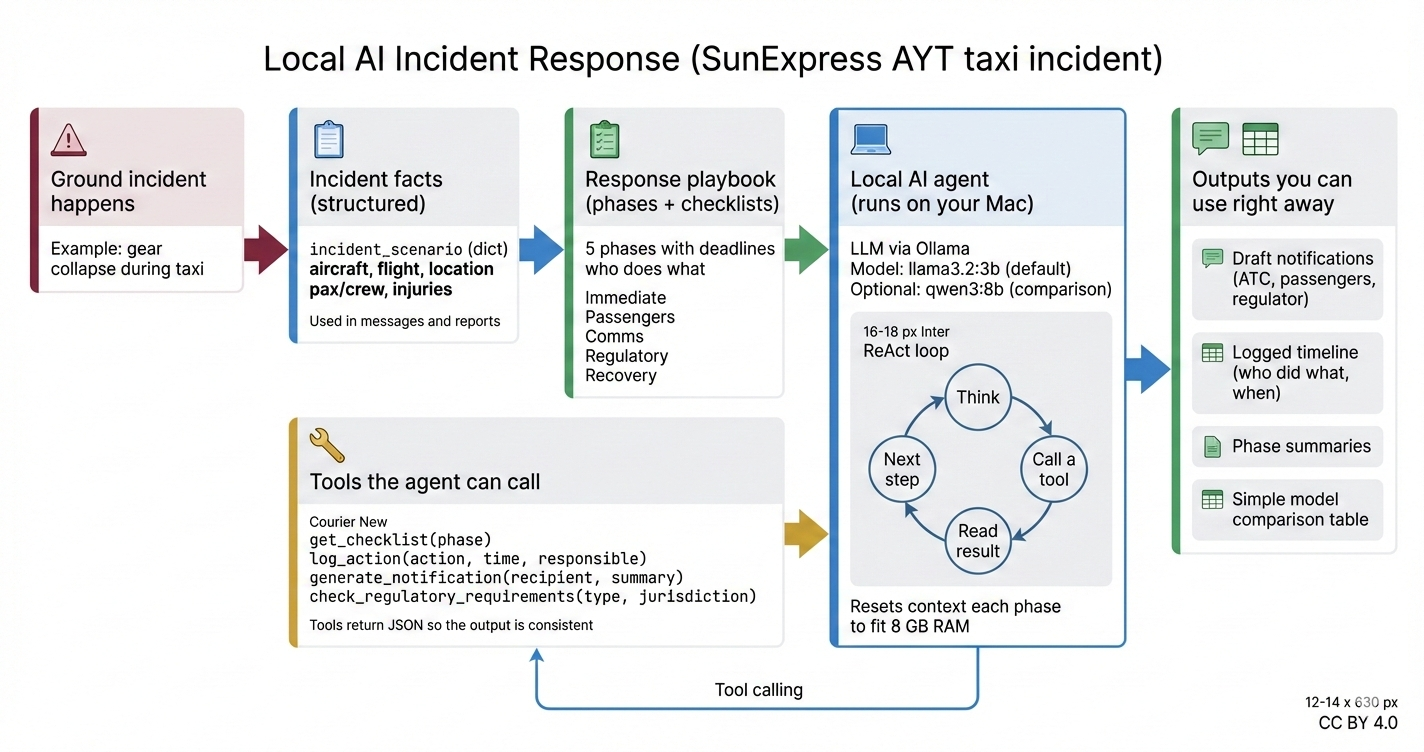

In [32]:
show_image("assets/pipeline-dev.png", width=900)

Figure: This diagram shows the end-to-end flow of the notebook. We start with the incident facts (flight, aircraft, location, passengers) and a response playbook that lists the phases and deadlines. A local AI agent runs on your Mac using Ollama and works in a simple loop: it decides the next step, calls a tool, reads the result, and continues. The agent can fetch the right checklist, log actions into a timeline, draft messages for ATC, passengers, and regulators, and check reporting deadlines. The output is a timeline and ready-to-review message drafts that help a human team respond faster and more consistently during a disruption.


## What is Agentic AI?

Most people have interacted with AI chatbots that answer questions based on what they already know. You type something, the model generates a response, and that is the end of it. This is a single-turn interaction: one question, one answer.

**Retrieval-Augmented Generation (RAG)** extends this by letting the model look up information from documents before answering. Think of it like giving the chatbot a reference manual it can search. RAG is great when the task is "find and summarize relevant information" [3]. For example, "What does the maintenance manual say about gear strut inspections?"

But incident response is not just about retrieving information. It is about *doing things in sequence*: first check for injuries, then secure the area, then notify ATC, then handle passengers, and so on. Each step may depend on the outcome of the previous one. A RAG system would need a human to drive every step manually.

**Agentic AI** is different. An AI agent can *plan*, *decide which tools to use*, and *take actions* in a loop until a goal is achieved [4]. Instead of a single question-answer cycle, the agent works through a series of steps like a human operator would. It can call different tools (checklists, notification generators, regulatory databases) based on the current situation. The agent follows a reasoning pattern often called **ReAct** (Reason + Act): it thinks about what to do next, takes an action, observes the result, then decides the next step [5].

For incident response, this matters because:
- **RAG** can tell you what the procedures are (retrieval).
- **An agent** can walk you through the procedures step by step, generate the actual notifications, track what has been done, and flag what is still pending (action).

In our demo, we give the agent a set of tools (checklist lookup, action logging, notification drafting, regulatory requirements) and let it work through the incident response playbook autonomously. The agent runs on a local LLM (`llama3.2:3b` via Ollama) so all data stays on your machine, which is important when dealing with sensitive operational information.

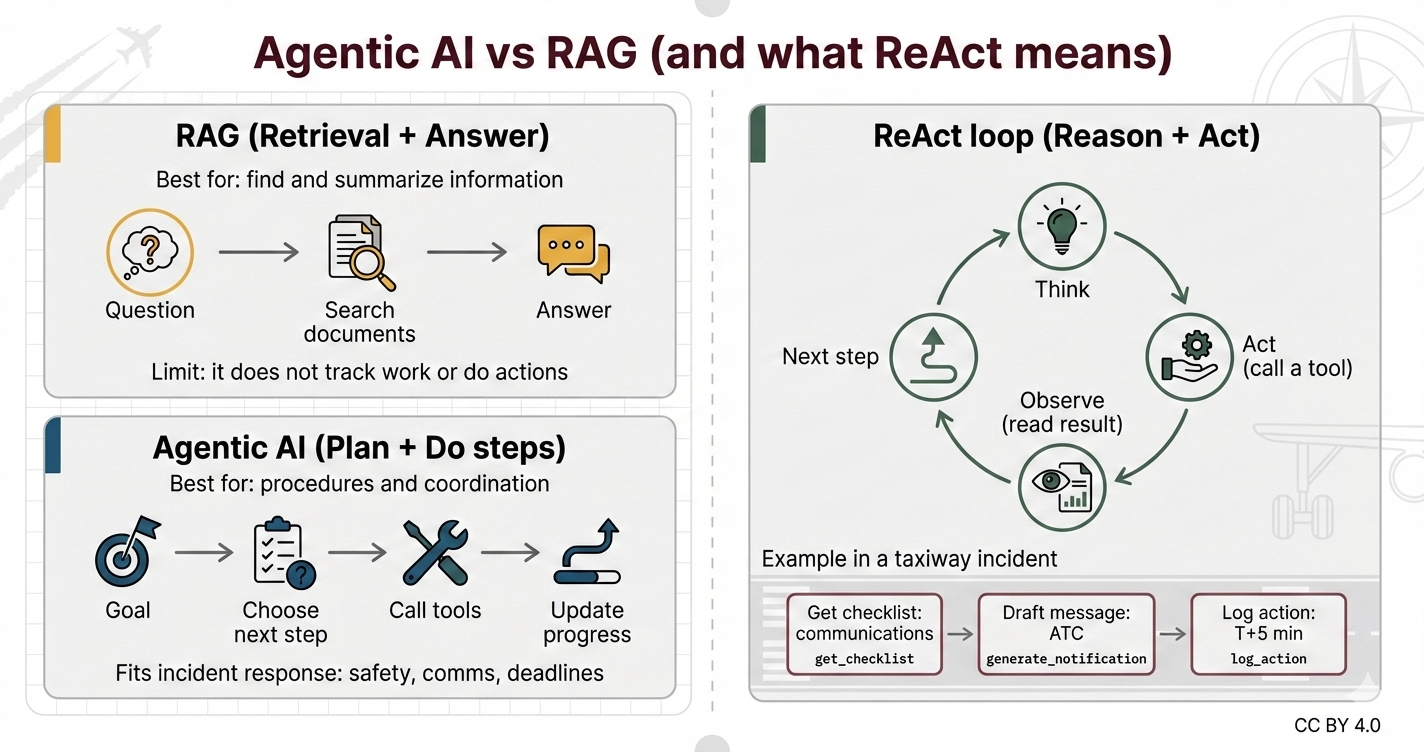

In [33]:
show_image("assets/aitheory-dev.png", width=900)

Figure: This diagram compares two ways of using an LLM. RAG is best when you want the model to look up information in documents and answer a question. Incident response needs more than answers. You must do tasks in order, track what is done, and produce concrete outputs like notifications and an action timeline. Agentic AI uses a simple ReAct loop. It thinks about the next step, calls the right tool, reads the tool result, and repeats until the phase is complete.


### LLM Connectivity Check

Before building the agent, let us verify that Ollama is running and we can communicate with the `llama3.2:3b` model. This 3-billion parameter model is small enough to run comfortably on an 8 GB Mac while still being capable of following instructions and calling tools.

In [3]:
# Initialize the local LLM
llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.1,
    num_predict=512,
)

# Quick connectivity test
test_response = llm.invoke([HumanMessage(content="In one sentence, what is a landing gear strut?")])
print("LLM Response:", test_response.content)

LLM Response: A landing gear strut is a structural component of an aircraft's landing gear system that connects the main landing gear to the fuselage and provides support for the weight of the plane during takeoff, landing, and taxiing.


In [4]:
# Clean up test variable
del test_response
print("Connectivity verified. Ready to build the agent.")

Connectivity verified. Ready to build the agent.


## Incident Playbook Data

> **DISCLAIMER**: The incident response playbook, timelines, and notification templates in this notebook are **synthetic and simplified** for demonstration purposes. They are loosely based on general aviation incident management practices and publicly available ICAO guidelines. This is not an actual airline standard operating procedure. This demonstration is for educational purposes only to illustrate how AI agents can assist in structured workflows.

### Incident Scenario

We start by defining the incident as a structured dictionary. This captures the facts from the SunExpress event: aircraft type, registration, flight number, location, and a brief description. The agent will use this information when generating notifications, checklists, and timelines.

In a production system, this data would come from an operations database or be entered by a duty manager. Here, we hard-code it based on publicly reported details [1][2].

In [5]:
incident_scenario = {
    "aircraft_type": "Boeing 737-800",
    "registration": "TC-SOB",
    "flight_number": "XQ7646",
    "operator": "SunExpress",
    "origin": "Antalya (AYT)",
    "destination": "Gaziantep (GZT)",
    "date": "2026-02-13",
    "time_utc": "08:45",
    "location": "Taxiway J, Antalya Airport (AYT)",
    "description": (
        "Left main landing gear collapsed during taxi for departure. "
        "Aircraft resting on left engine nacelle, blocking Taxiway J. "
        "No injuries reported."
    ),
    "passengers": 156,
    "crew": 6,
    "injuries": 0,
    "taxiway_blocked": True,
    "aircraft_operable": False,
}

print("Incident scenario defined.")
print(f"  Flight: {incident_scenario['operator']} {incident_scenario['flight_number']}")
print(f"  Aircraft: {incident_scenario['aircraft_type']} ({incident_scenario['registration']})")
print(f"  Location: {incident_scenario['location']}")
print(f"  Pax/Crew: {incident_scenario['passengers']}/{incident_scenario['crew']}")
print(f"  Description: {incident_scenario['description']}")

Incident scenario defined.
  Flight: SunExpress XQ7646
  Aircraft: Boeing 737-800 (TC-SOB)
  Location: Taxiway J, Antalya Airport (AYT)
  Pax/Crew: 156/6
  Description: Left main landing gear collapsed during taxi for departure. Aircraft resting on left engine nacelle, blocking Taxiway J. No injuries reported.


### Incident Response Playbook

An incident response playbook is a predefined set of procedures that operations teams follow when something goes wrong. It breaks the response into phases, each with specific checklist items, responsible parties, and time deadlines.

Our playbook has five phases, modeled loosely on ICAO Annex 13 guidelines [6] and general airline ground incident procedures:

1. **Immediate Response** - Safety first: secure the area, check for injuries, stop taxiway traffic
2. **Passenger Handling** - Get people off the aircraft safely and to a holding area
3. **Communications** - Notify ATC, airport operations, company operations center, and passengers
4. **Regulatory** - File required reports with civil aviation authorities and preserve evidence
5. **Recovery** - Remove the aircraft, inspect the taxiway, restore normal operations

Each checklist item has a responsible party (who does it) and a deadline (how quickly it must be done after the incident).

In [6]:
incident_playbook = {
    "immediate_response": {
        "name": "Immediate Response",
        "description": "Secure the area and ensure safety of all persons.",
        "checklist": [
            {
                "item": "Confirm no fire or fuel leak at the aircraft",
                "responsible": "Airport Fire Service",
                "deadline_minutes": 2,
            },
            {
                "item": "Verify no injuries among passengers or crew",
                "responsible": "Cabin Crew Lead",
                "deadline_minutes": 3,
            },
            {
                "item": "Request ATC to halt all taxiway traffic in the affected zone",
                "responsible": "Flight Crew (Captain)",
                "deadline_minutes": 2,
            },
            {
                "item": "Establish a safety perimeter around the aircraft",
                "responsible": "Airport Security",
                "deadline_minutes": 5,
            },
            {
                "item": "Deploy ground stairs for emergency deplaning if slides not used",
                "responsible": "Ground Handling Team",
                "deadline_minutes": 5,
            },
        ],
    },
    "passenger_handling": {
        "name": "Passenger Handling",
        "description": "Safely deplane passengers and manage their onward travel.",
        "checklist": [
            {
                "item": "Begin orderly deplaning via ground stairs",
                "responsible": "Cabin Crew Lead",
                "deadline_minutes": 10,
            },
            {
                "item": "Transport passengers to terminal holding area via bus",
                "responsible": "Ground Handling Team",
                "deadline_minutes": 20,
            },
            {
                "item": "Set up passenger assistance desk with rebooking capability",
                "responsible": "Station Manager",
                "deadline_minutes": 30,
            },
            {
                "item": "Provide refreshments and regular status updates to passengers",
                "responsible": "Customer Service Team",
                "deadline_minutes": 30,
            },
            {
                "item": "Arrange replacement aircraft or alternative flights",
                "responsible": "Operations Control Center (OCC)",
                "deadline_minutes": 60,
            },
        ],
    },
    "communications": {
        "name": "Communications",
        "description": "Notify all relevant parties about the incident.",
        "checklist": [
            {
                "item": "Send initial NOTAM/advisory to ATC about blocked taxiway",
                "responsible": "Flight Crew (Captain)",
                "deadline_minutes": 5,
            },
            {
                "item": "Notify Airport Operations Center of taxiway blockage",
                "responsible": "Station Manager",
                "deadline_minutes": 5,
            },
            {
                "item": "Contact company Operations Control Center with situation report",
                "responsible": "Station Manager",
                "deadline_minutes": 10,
            },
            {
                "item": "Prepare initial passenger communication (PA or written notice)",
                "responsible": "Passenger Service Team",
                "deadline_minutes": 15,
            },
            {
                "item": "Brief media/PR team for potential press inquiries",
                "responsible": "Station Manager",
                "deadline_minutes": 30,
            },
        ],
    },
    "regulatory": {
        "name": "Regulatory Compliance",
        "description": "Meet all mandatory reporting and evidence preservation requirements.",
        "checklist": [
            {
                "item": "File preliminary notification with Turkish DGCA (SHGM)",
                "responsible": "Safety Department",
                "deadline_minutes": 60,
            },
            {
                "item": "Notify aircraft manufacturer (Boeing) per maintenance agreement",
                "responsible": "Aircraft Maintenance & Engineering",
                "deadline_minutes": 120,
            },
            {
                "item": "Preserve flight data recorder (FDR) and cockpit voice recorder (CVR) data",
                "responsible": "Aircraft Maintenance & Engineering",
                "deadline_minutes": 30,
            },
            {
                "item": "Photograph and document aircraft position, gear damage, and ground marks",
                "responsible": "Safety Department",
                "deadline_minutes": 20,
            },
            {
                "item": "Secure maintenance records for the affected landing gear assembly",
                "responsible": "Aircraft Maintenance & Engineering",
                "deadline_minutes": 120,
            },
        ],
    },
    "recovery": {
        "name": "Recovery",
        "description": "Remove the aircraft and restore normal airport operations.",
        "checklist": [
            {
                "item": "Coordinate aircraft recovery plan with airport authority",
                "responsible": "Aircraft Maintenance & Engineering",
                "deadline_minutes": 120,
            },
            {
                "item": "Position recovery equipment (jacks, airbags, tow vehicles)",
                "responsible": "Ground Handling Team",
                "deadline_minutes": 180,
            },
            {
                "item": "Lift and remove aircraft from taxiway",
                "responsible": "Aircraft Recovery Team",
                "deadline_minutes": 240,
            },
            {
                "item": "Inspect taxiway surface for damage before reopening",
                "responsible": "Airport Maintenance",
                "deadline_minutes": 270,
            },
            {
                "item": "Issue NOTAM cancellation and restore normal taxiway flow",
                "responsible": "Airport Operations Center",
                "deadline_minutes": 280,
            },
        ],
    },
}

print(f"Playbook defined with {len(incident_playbook)} phases.")
for phase_key, phase_data in incident_playbook.items():
    print(f"  {phase_data['name']}: {len(phase_data['checklist'])} checklist items")

Playbook defined with 5 phases.
  Immediate Response: 5 checklist items
  Passenger Handling: 5 checklist items
  Communications: 5 checklist items
  Regulatory Compliance: 5 checklist items
  Recovery: 5 checklist items


Let us display the playbook in a structured format so we can see the full picture before handing it to the agent. Each phase lists its checklist items, who is responsible, and the deadline in minutes from the incident start.

In [7]:
for phase_key, phase_data in incident_playbook.items():
    table = Table(
        title=f"{phase_data['name']}",
        title_style="bold",
        show_lines=True,
        width=100,
    )
    table.add_column("#", style="dim", width=3)
    table.add_column("Checklist Item", width=50)
    table.add_column("Responsible Party", width=25)
    table.add_column("Deadline", width=12)

    for i, item in enumerate(phase_data["checklist"], 1):
        deadline = f"{item['deadline_minutes']} min"
        table.add_row(str(i), item["item"], item["responsible"], deadline)

    console.print(table)
    console.print()

                                         Immediate Response                                         
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ #  ┃ Checklist Item                                    ┃ Responsible Party         ┃ Deadline    ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1  │ Confirm no fire or fuel leak at the aircraft      │ Airport Fire Service      │ 2 min       │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 2  │ Verify no injuries among passengers or crew       │ Cabin Crew Lead           │ 3 min       │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 3  │ Request ATC to halt all taxiway traffic in the    │ Flight Crew (Captain)     │ 2 min       │
│    │ affected zone                                     │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 4  │ Establish a safety perimeter around the aircraft  │ Airport Security          │ 5 min       │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 5  │ Deploy ground stairs for emergency deplaning if   │ Ground Handling Team      │ 5 min       │
│    │ slides not used                                   │                           │             │
└────┴───────────────────────────────────────────────────┴───────────────────────────┴─────────────┘

                                         Passenger Handling                                         
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ #  ┃ Checklist Item                                    ┃ Responsible Party         ┃ Deadline    ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1  │ Begin orderly deplaning via ground stairs         │ Cabin Crew Lead           │ 10 min      │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 2  │ Transport passengers to terminal holding area via │ Ground Handling Team      │ 20 min      │
│    │ bus                                               │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 3  │ Set up passenger assistance desk with rebooking   │ Station Manager           │ 30 min      │
│    │ capability                                        │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 4  │ Provide refreshments and regular status updates   │ Customer Service Team     │ 30 min      │
│    │ to passengers                                     │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 5  │ Arrange replacement aircraft or alternative       │ Operations Control Center │ 60 min      │
│    │ flights                                           │ (OCC)                     │             │
└────┴───────────────────────────────────────────────────┴───────────────────────────┴─────────────┘

                                           Communications                                           
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ #  ┃ Checklist Item                                    ┃ Responsible Party         ┃ Deadline    ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1  │ Send initial NOTAM/advisory to ATC about blocked  │ Flight Crew (Captain)     │ 5 min       │
│    │ taxiway                                           │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 2  │ Notify Airport Operations Center of taxiway       │ Station Manager           │ 5 min       │
│    │ blockage                                          │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 3  │ Contact company Operations Control Center with    │ Station Manager           │ 10 min      │
│    │ situation report                                  │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 4  │ Prepare initial passenger communication (PA or    │ Passenger Service Team    │ 15 min      │
│    │ written notice)                                   │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 5  │ Brief media/PR team for potential press inquiries │ Station Manager           │ 30 min      │
└────┴───────────────────────────────────────────────────┴───────────────────────────┴─────────────┘

                                       Regulatory Compliance                                        
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ #  ┃ Checklist Item                                    ┃ Responsible Party         ┃ Deadline    ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1  │ File preliminary notification with Turkish DGCA   │ Safety Department         │ 60 min      │
│    │ (SHGM)                                            │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 2  │ Notify aircraft manufacturer (Boeing) per         │ Aircraft Maintenance &    │ 120 min     │
│    │ maintenance agreement                             │ Engineering               │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 3  │ Preserve flight data recorder (FDR) and cockpit   │ Aircraft Maintenance &    │ 30 min      │
│    │ voice recorder (CVR) data                         │ Engineering               │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 4  │ Photograph and document aircraft position, gear   │ Safety Department         │ 20 min      │
│    │ damage, and ground marks                          │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 5  │ Secure maintenance records for the affected       │ Aircraft Maintenance &    │ 120 min     │
│    │ landing gear assembly                             │ Engineering               │             │
└────┴───────────────────────────────────────────────────┴───────────────────────────┴─────────────┘

                                              Recovery                                              
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ #  ┃ Checklist Item                                    ┃ Responsible Party         ┃ Deadline    ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1  │ Coordinate aircraft recovery plan with airport    │ Aircraft Maintenance &    │ 120 min     │
│    │ authority                                         │ Engineering               │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 2  │ Position recovery equipment (jacks, airbags, tow  │ Ground Handling Team      │ 180 min     │
│    │ vehicles)                                         │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 3  │ Lift and remove aircraft from taxiway             │ Aircraft Recovery Team    │ 240 min     │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 4  │ Inspect taxiway surface for damage before         │ Airport Maintenance       │ 270 min     │
│    │ reopening                                         │                           │             │
├────┼───────────────────────────────────────────────────┼───────────────────────────┼─────────────┤
│ 5  │ Issue NOTAM cancellation and restore normal       │ Airport Operations Center │ 280 min     │
│    │ taxiway flow                                      │                           │             │
└────┴───────────────────────────────────────────────────┴───────────────────────────┴─────────────┘

## Tool Definitions and Schemas

### Structured Outputs with Pydantic

When an LLM generates free-form text, parsing the result programmatically is fragile. A small change in wording can break downstream logic. **Structured outputs** solve this by forcing the model's response into a predefined schema, similar to how a database enforces column types [7].

We use [Pydantic](https://docs.pydantic.dev/) models to define what the agent's outputs should look like. Each model is a Python class with typed fields. When the agent returns a result, Pydantic validates it automatically. If a field is missing or has the wrong type, we get a clear error rather than silent garbage.

For incident response, structured outputs are especially important because:
- Checklists need consistent fields (item, responsible party, deadline) so they can be displayed in tables and tracked.
- Notifications need a fixed format (recipient, subject, body) so they can be routed to the right communication channel.
- Regulatory requirements need deadlines and authority names that match real-world reporting obligations.

In [8]:
# Pydantic models for structured agent outputs

class ChecklistItem(BaseModel):
    """A single checklist item within an incident response phase."""
    item: str = Field(description="Description of the action to take")
    responsible: str = Field(description="Person or team responsible")
    deadline_minutes: int = Field(description="Deadline in minutes from incident start")
    completed: bool = Field(default=False, description="Whether this item has been completed")


class IncidentAssessment(BaseModel):
    """Initial assessment of an incident's severity and status."""
    severity: str = Field(description="Severity level: minor, moderate, or major")
    injuries: int = Field(description="Number of reported injuries")
    aircraft_operable: bool = Field(description="Whether the aircraft can move under its own power")
    blocking_infrastructure: bool = Field(description="Whether the aircraft is blocking taxiway or runway")
    description: str = Field(description="Brief summary of the situation")


class ActionRecommendation(BaseModel):
    """A recommended action for the operations team."""
    action: str = Field(description="What needs to be done")
    priority: str = Field(description="Priority level: immediate, urgent, or routine")
    deadline_minutes: int = Field(description="Minutes from incident start to complete this action")
    responsible_party: str = Field(description="Who should carry out this action")
    phase: str = Field(description="Which playbook phase this belongs to")


class NotificationDraft(BaseModel):
    """A draft notification message for a specific recipient."""
    recipient: str = Field(description="Who receives this notification")
    subject: str = Field(description="Subject line of the notification")
    body: str = Field(description="Full text of the notification message")
    urgency: str = Field(description="Urgency level: immediate, high, or normal")


print("Pydantic models defined:")
for model in [ChecklistItem, IncidentAssessment, ActionRecommendation, NotificationDraft]:
    fields = ", ".join(model.model_fields.keys())
    print(f"  {model.__name__}: {fields}")

Pydantic models defined:
  ChecklistItem: item, responsible, deadline_minutes, completed
  IncidentAssessment: severity, injuries, aircraft_operable, blocking_infrastructure, description
  ActionRecommendation: action, priority, deadline_minutes, responsible_party, phase
  NotificationDraft: recipient, subject, body, urgency


### Agent Tools

In LangChain, a **tool** is a Python function that the LLM can decide to call on its own [8]. The agent sees a description of each tool (its name, what it does, what arguments it takes) and chooses which tools to invoke based on the current situation. This is called **tool calling** or **function calling**.

Think of it like giving an airine employee a toolkit and a manual. The manual (system prompt) explains their role. The toolkit (functions) lets them actually do things: look up checklists, log actions, draft notifications. The airline employee (agent) reads the situation, picks the right tool, uses it, reads the result, and decides what to do next.

We define four tools for our incident response agent:

| Tool | Purpose |
|------|---------|
| `get_checklist` | Retrieve the checklist for a specific incident phase |
| `log_action` | Record an action taken, with timestamp and responsible party |
| `generate_notification` | Create a formatted notification for a given recipient |
| `check_regulatory_requirements` | Look up mandatory reporting deadlines for a given jurisdiction |

Each tool is decorated with `@tool` from LangChain, which automatically generates the schema the LLM needs to call it correctly.

In [9]:
# In-memory incident timeline (shared across tool calls)
incident_timeline = []

@tool
def get_checklist(phase: str) -> str:
    """Retrieve the checklist items for a specific incident response phase.

    Args:
        phase: The phase name. Must be one of: immediate_response, passenger_handling,
               communications, regulatory, recovery.

    Returns:
        A JSON string with the phase name and its checklist items.
    """
    if phase not in incident_playbook:
        available = ", ".join(incident_playbook.keys())
        return json.dumps({
            "error": f"Unknown phase '{phase}'. Available phases: {available}"
        })

    phase_data = incident_playbook[phase]
    result = {
        "phase": phase_data["name"],
        "description": phase_data["description"],
        "checklist": phase_data["checklist"],
    }
    return json.dumps(result, indent=2)


print(f"Tool defined: get_checklist")
print(f"  Description: {get_checklist.description[:80]}...")

# Quick test
sample = json.loads(get_checklist.invoke({"phase": "immediate_response"}))
print(f"  Test: '{sample['phase']}' phase has {len(sample['checklist'])} items")

Tool defined: get_checklist
  Description: Retrieve the checklist items for a specific incident response phase.

    Args:
...
  Test: 'Immediate Response' phase has 5 items


In [10]:
@tool
def log_action(action: str, timestamp: str, responsible: str) -> str:
    """Log an action taken during incident response to the incident timeline.

    Args:
        action: Description of the action that was taken.
        timestamp: When the action occurred (ISO format or relative like 'T+5 min').
        responsible: Person or team who performed the action.

    Returns:
        Confirmation message with the logged entry number.
    """
    entry = {
        "entry_number": len(incident_timeline) + 1,
        "action": action,
        "timestamp": timestamp,
        "responsible": responsible,
    }
    incident_timeline.append(entry)
    return json.dumps({
        "status": "logged",
        "entry_number": entry["entry_number"],
        "message": f"Action logged as entry #{entry['entry_number']}"
    })


print(f"Tool defined: log_action")
print(f"  Description: {log_action.description[:80]}...")

# Quick test
result = json.loads(log_action.invoke({
    "action": "Test entry - will be cleared",
    "timestamp": "T+0 min",
    "responsible": "System"
}))
print(f"  Test: {result['message']}")

# Clear the test entry
incident_timeline.clear()
print(f"  Timeline cleared for actual agent use.")

Tool defined: log_action
  Description: Log an action taken during incident response to the incident timeline.

    Args...
  Test: Action logged as entry #1
  Timeline cleared for actual agent use.


In [11]:
@tool
def generate_notification(recipient: str, incident_summary: str) -> str:
    """Generate a formatted notification message for a specific recipient about the incident.

    Args:
        recipient: Who receives the notification (e.g., 'ATC', 'Airport Operations',
                   'Operations Control Center', 'Passengers', 'Turkish DGCA').
        incident_summary: Brief description of the incident to include in the notification.

    Returns:
        A JSON string containing the notification with recipient, subject, body, and urgency.
    """
    # Notification templates vary by recipient type
    templates = {
        "ATC": {
            "subject": f"NOTAM Advisory - Taxiway Blockage at {incident_scenario['origin']}",
            "urgency": "immediate",
            "body": (
                f"ATTENTION ATC: {incident_scenario['operator']} flight {incident_scenario['flight_number']} "
                f"({incident_scenario['aircraft_type']}, {incident_scenario['registration']}) "
                f"has experienced a landing gear failure on {incident_scenario['location']}. "
                f"Aircraft is immobile and blocking the taxiway. "
                f"{incident_summary} "
                f"Request immediate closure of affected taxiway segment. "
                f"Time of incident: {incident_scenario['date']} {incident_scenario['time_utc']} UTC."
            ),
        },
        "Airport Operations": {
            "subject": f"Ground Incident - Aircraft Blocking {incident_scenario['location']}",
            "urgency": "immediate",
            "body": (
                f"INCIDENT REPORT: {incident_scenario['operator']} {incident_scenario['flight_number']} "
                f"({incident_scenario['registration']}) - left main landing gear collapse during taxi. "
                f"Aircraft is resting on engine nacelle at {incident_scenario['location']}. "
                f"{incident_summary} "
                f"Passengers on board: {incident_scenario['passengers']}. Crew: {incident_scenario['crew']}. "
                f"Injuries reported: {incident_scenario['injuries']}. "
                f"Request ground support for passenger deplaning and taxiway recovery operations."
            ),
        },
        "Operations Control Center": {
            "subject": f"SITREP - {incident_scenario['flight_number']} Ground Incident at {incident_scenario['origin']}",
            "urgency": "high",
            "body": (
                f"SITUATION REPORT\n"
                f"Flight: {incident_scenario['operator']} {incident_scenario['flight_number']}\n"
                f"Aircraft: {incident_scenario['aircraft_type']} ({incident_scenario['registration']})\n"
                f"Route: {incident_scenario['origin']} to {incident_scenario['destination']}\n"
                f"Incident: Left main gear collapse during taxi for departure\n"
                f"Location: {incident_scenario['location']}\n"
                f"Time: {incident_scenario['date']} {incident_scenario['time_utc']} UTC\n"
                f"Passengers: {incident_scenario['passengers']} | Crew: {incident_scenario['crew']}\n"
                f"Injuries: {incident_scenario['injuries']}\n"
                f"Aircraft status: Inoperable, blocking taxiway\n"
                f"{incident_summary}\n"
                f"Action required: Arrange replacement aircraft for {incident_scenario['passengers']} passengers."
            ),
        },
        "Passengers": {
            "subject": f"Flight {incident_scenario['flight_number']} - Important Update",
            "urgency": "high",
            "body": (
                f"Dear passengers of flight {incident_scenario['flight_number']} "
                f"from {incident_scenario['origin']} to {incident_scenario['destination']},\n\n"
                f"We regret to inform you that our aircraft has experienced a technical issue "
                f"that requires us to deplane at the current position. {incident_summary}\n\n"
                f"Your safety is our priority. Ground transportation will bring you to the terminal "
                f"where our team will assist with rebooking arrangements. "
                f"We will provide regular updates on the replacement aircraft status.\n\n"
                f"We sincerely apologize for the inconvenience and appreciate your patience.\n\n"
                f"{incident_scenario['operator']} Ground Operations"
            ),
        },
        "Turkish DGCA": {
            "subject": f"Preliminary Incident Notification - {incident_scenario['registration']}",
            "urgency": "high",
            "body": (
                f"PRELIMINARY INCIDENT NOTIFICATION\n"
                f"Submitted to: Directorate General of Civil Aviation (SHGM), Republic of Turkey\n\n"
                f"Operator: {incident_scenario['operator']}\n"
                f"Flight: {incident_scenario['flight_number']}\n"
                f"Aircraft: {incident_scenario['aircraft_type']}, Registration {incident_scenario['registration']}\n"
                f"Date/Time: {incident_scenario['date']} {incident_scenario['time_utc']} UTC\n"
                f"Location: {incident_scenario['location']}\n\n"
                f"Nature of Event: Landing gear collapse (left main gear) during taxi for departure.\n"
                f"{incident_summary}\n\n"
                f"Injuries: None reported ({incident_scenario['passengers']} passengers, "
                f"{incident_scenario['crew']} crew).\n"
                f"Aircraft Damage: Substantial (gear assembly, engine nacelle contact with ground).\n"
                f"Infrastructure: Taxiway blocked; NOTAM issued.\n\n"
                f"FDR/CVR data is being preserved. Full report to follow within 72 hours."
            ),
        },
    }

    # Use matching template or generate a generic one
    if recipient in templates:
        notification = templates[recipient]
    else:
        notification = {
            "subject": f"Incident Notification - {incident_scenario['flight_number']}",
            "urgency": "normal",
            "body": (
                f"This is to notify you regarding an incident involving "
                f"{incident_scenario['operator']} flight {incident_scenario['flight_number']}. "
                f"{incident_summary} "
                f"Please contact the operations team for further details."
            ),
        }

    result = {
        "recipient": recipient,
        "subject": notification["subject"],
        "body": notification["body"],
        "urgency": notification["urgency"],
    }
    return json.dumps(result, indent=2)


print(f"Tool defined: generate_notification")
print(f"  Description: {generate_notification.description[:80]}...")

# Quick test
sample = json.loads(generate_notification.invoke({
    "recipient": "ATC",
    "incident_summary": "No fire, no fuel leak. All persons safe."
}))
print(f"  Test: Notification for '{sample['recipient']}' - urgency: {sample['urgency']}")

Tool defined: generate_notification
  Description: Generate a formatted notification message for a specific recipient about the inc...
  Test: Notification for 'ATC' - urgency: immediate


In [12]:
@tool
def check_regulatory_requirements(incident_type: str, jurisdiction: str) -> str:
    """Look up mandatory regulatory reporting requirements for a given incident type and jurisdiction.

    Args:
        incident_type: Type of incident (e.g., 'landing_gear_failure', 'runway_excursion',
                       'engine_failure', 'ground_collision').
        jurisdiction: Country or regulatory body (e.g., 'Turkey', 'EU', 'USA').

    Returns:
        A JSON string listing regulatory requirements with authority, deadline, and description.
    """
    # Regulatory requirements database (simplified for demonstration)
    requirements_db = {
        "Turkey": [
            {
                "authority": "SHGM (Directorate General of Civil Aviation)",
                "requirement": "Preliminary incident notification",
                "deadline": "Within 1 hour of the incident",
                "deadline_minutes": 60,
                "reference": "Turkish Civil Aviation Regulation SHT-OPS, aligned with ICAO Annex 13",
                "details": (
                    "The operator must notify SHGM immediately for any accident or serious incident. "
                    "A landing gear collapse with substantial aircraft damage qualifies as an accident "
                    "under ICAO Annex 13 definitions."
                ),
            },
            {
                "authority": "SHGM (Directorate General of Civil Aviation)",
                "requirement": "Formal preliminary report submission",
                "deadline": "Within 72 hours",
                "deadline_minutes": 4320,
                "reference": "ICAO Annex 13 Chapter 7",
                "details": (
                    "A written preliminary report must be sent to SHGM and, if applicable, "
                    "to the State of Design (USA/FAA for Boeing aircraft) and ICAO."
                ),
            },
            {
                "authority": "BEA / NTSB (State of Design)",
                "requirement": "Notify State of Design and State of Manufacture",
                "deadline": "As soon as practicable",
                "deadline_minutes": 120,
                "reference": "ICAO Annex 13, Chapter 4.4",
                "details": (
                    "Since the Boeing 737-800 is designed and manufactured in the USA, "
                    "the NTSB (as the accident investigation authority of the State of Design) "
                    "must be notified. They may choose to send an accredited representative."
                ),
            },
            {
                "authority": "Boeing Commercial Airplanes",
                "requirement": "Manufacturer notification per maintenance agreement",
                "deadline": "Within 2 hours",
                "deadline_minutes": 120,
                "reference": "Operator-manufacturer maintenance agreement",
                "details": (
                    "The operator's maintenance agreement with Boeing typically requires "
                    "prompt notification of structural failures. Boeing's Product Safety team "
                    "may issue a fleet-wide inspection bulletin if a systemic issue is suspected."
                ),
            },
            {
                "authority": "Airport Authority (DHMI)",
                "requirement": "Airport incident report",
                "deadline": "Within 4 hours",
                "deadline_minutes": 240,
                "reference": "Airport operations manual",
                "details": (
                    "The airport authority requires a formal incident report for any event "
                    "that disrupts normal airport operations, including taxiway closures."
                ),
            },
        ],
        "EU": [
            {
                "authority": "EASA (European Union Aviation Safety Agency)",
                "requirement": "Occurrence report via ECCAIRS",
                "deadline": "Within 72 hours",
                "deadline_minutes": 4320,
                "reference": "Regulation (EU) No 376/2014",
                "details": (
                    "EU operators must report occurrences through the ECCAIRS system. "
                    "Landing gear failures are classified as a reportable occurrence."
                ),
            },
        ],
        "USA": [
            {
                "authority": "NTSB (National Transportation Safety Board)",
                "requirement": "Immediate notification",
                "deadline": "Immediately (within 1 hour)",
                "deadline_minutes": 60,
                "reference": "49 CFR 830.5",
                "details": (
                    "The operator must notify the NTSB immediately for any aircraft accident. "
                    "Landing gear collapse with substantial damage meets the accident definition."
                ),
            },
            {
                "authority": "FAA (Federal Aviation Administration)",
                "requirement": "Preliminary accident/incident report",
                "deadline": "Within 10 days",
                "deadline_minutes": 14400,
                "reference": "49 CFR 830.15",
                "details": "A formal written report must be filed with the NTSB within 10 days.",
            },
        ],
    }

    requirements = requirements_db.get(jurisdiction, [])

    if not requirements:
        available = ", ".join(requirements_db.keys())
        return json.dumps({
            "jurisdiction": jurisdiction,
            "incident_type": incident_type,
            "requirements": [],
            "note": f"No specific data for '{jurisdiction}'. Available: {available}"
        })

    result = {
        "jurisdiction": jurisdiction,
        "incident_type": incident_type,
        "total_requirements": len(requirements),
        "requirements": requirements,
    }
    return json.dumps(result, indent=2)


print(f"Tool defined: check_regulatory_requirements")
print(f"  Description: {check_regulatory_requirements.description[:80]}...")

# Quick test
sample = json.loads(check_regulatory_requirements.invoke({
    "incident_type": "landing_gear_failure",
    "jurisdiction": "Turkey"
}))
print(f"  Test: {sample['total_requirements']} requirements found for {sample['jurisdiction']}")

Tool defined: check_regulatory_requirements
  Description: Look up mandatory regulatory reporting requirements for a given incident type an...
  Test: 5 requirements found for Turkey


### Binding Tools to the LLM

With the tools defined, we need to tell the LLM about them. LangChain's `bind_tools` method takes our Python functions and converts their signatures and docstrings into a format the model understands [8]. After binding, when the model decides it needs information (say, the checklist for the "communications" phase), it will output a structured tool call request instead of trying to hallucinate the answer.

This is the fundamental difference between a chatbot and an agent: the agent can *reach out* to external functions rather than relying solely on what it memorized during training.

In [13]:
# Collect all tools
tools = [get_checklist, log_action, generate_notification, check_regulatory_requirements]

# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

print(f"Bound {len(tools)} tools to the LLM:")
for t in tools:
    print(f"  - {t.name}")

Bound 4 tools to the LLM:
  - get_checklist
  - log_action
  - generate_notification
  - check_regulatory_requirements


Let us verify that the LLM can actually call tools. We send it a message that should trigger a tool call, and check that it responds with a proper tool invocation rather than a text answer.

In [14]:
# Test: Ask the LLM something that should trigger a tool call
test_message = HumanMessage(
    content="What are the checklist items for the immediate_response phase?"
)

test_result = llm_with_tools.invoke([test_message])

# Check if the model made a tool call
if test_result.tool_calls:
    print("Tool calling works. The LLM requested:")
    for tc in test_result.tool_calls:
        print(f"  Tool: {tc['name']}")
        print(f"  Args: {tc['args']}")
else:
    print("No tool call detected. The LLM responded with text:")
    print(f"  {test_result.content[:200]}")

del test_message, test_result
print("\nTool binding verified. Ready to build the agent.")

Tool calling works. The LLM requested:
  Tool: get_checklist
  Args: {'phase': 'immediate_response'}

Tool binding verified. Ready to build the agent.


## Agent Construction and Execution

### Building the Agent Loop

Our agent uses a **ReAct** (Reason + Act) pattern [5]. Instead of making a single LLM call, the agent runs in a loop:

1. **Receive** the current situation and the phase to process
2. **Reason** about what to do next
3. **Act** by calling the right tool (get checklist, log action, draft notification, etc.)
4. **Observe** the tool's output
5. **Repeat** steps 2-4 until all necessary actions for that phase are done, then summarize

We implement this loop manually instead of using a pre-built agent framework like LangGraph. Manual control keeps the code easier to follow and lets us handle edge cases with the small 3B model. For each of the five incident phases, we start a fresh conversation with the agent, let it call whichever tools it needs, and collect the results.

Small language models (3B parameters) are good at following one instruction at a time but can lose track of multi-part instructions. To work around this, our agent loop supports **follow-up prompts**: after the agent completes its initial task (checklist retrieval and action logging), we inject additional directed instructions like "now draft a notification for ATC" or "now check regulatory requirements for Turkey." This keeps the model on track while still demonstrating genuine tool selection and execution.

The conversation history within a single phase is important. It lets the agent build on previous tool results. For example, after retrieving the checklist and logging actions, the agent can reference those results when drafting notifications. We reset the history between phases to keep context windows manageable on our 8 GB machine.

In [15]:
from langchain_core.messages import ToolMessage, AIMessage
from rich.panel import Panel

# Initialize agent LLM with extended output length and timeout
agent_llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.1,
    num_predict=1024,
)

# Bind existing tools to the agent LLM
agent_llm_with_tools = agent_llm.bind_tools(tools)

# Map tool names to callable functions
tool_map = {t.name: t for t in tools}

# System prompt: cast the agent as an incident response coordinator
AGENT_SYSTEM_PROMPT = (
    "You are an airline incident response coordinator managing a ground incident. "
    "Work through each playbook phase using the available tools.\n\n"
    "Instructions:\n"
    "- Call get_checklist to see what actions are needed in the given phase.\n"
    "- Call log_action to record completed actions with their timestamps and responsible parties.\n"
    "- Call generate_notification when external communications are needed.\n"
    "- Call check_regulatory_requirements for regulatory and compliance phases.\n"
    "- Be direct and factual. No emojis, no decorative formatting.\n"
    "- After using the necessary tools, provide a brief plain-text summary of what was accomplished."
)

print("Agent LLM initialized (llama3.2:3b, temperature=0.1, num_predict=1024)")
print(f"Tools bound: {', '.join(tool_map.keys())}")
print(f"System prompt: {len(AGENT_SYSTEM_PROMPT)} characters")

Agent LLM initialized (llama3.2:3b, temperature=0.1, num_predict=1024)
Tools bound: get_checklist, log_action, generate_notification, check_regulatory_requirements
System prompt: 619 characters


In [16]:
import time
import re


def _strip_think_tags(text):
    """Remove <think>...</think> blocks from model output (used by qwen3)."""
    if not text:
        return text
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()


def run_agent_phase(phase_key, extra_instruction="", follow_ups=None, max_steps=12):
    """Execute the agent for one incident response phase.

    Runs a ReAct loop: the LLM reasons, calls tools, observes results,
    and repeats until it produces a final text summary or hits max_steps.

    The follow_ups list lets us inject additional instructions after the agent
    produces its first text response. This is useful for directing the small 3B
    model to call specific tools (e.g., generate_notification) that it might
    skip on its own.
    """
    start_time = time.time()

    if follow_ups is None:
        follow_ups = []
    follow_up_queue = list(follow_ups)

    phase_info = incident_playbook[phase_key]
    phase_name = phase_info["name"]

    # Build the incident description once
    scenario_text = (
        f"Aircraft: {incident_scenario['aircraft_type']} ({incident_scenario['registration']}), "
        f"Flight: {incident_scenario['operator']} {incident_scenario['flight_number']}, "
        f"Location: {incident_scenario['location']}. "
        f"{incident_scenario['description']} "
        f"Passengers: {incident_scenario['passengers']}, Crew: {incident_scenario['crew']}, "
        f"Injuries: {incident_scenario['injuries']}."
    )

    # Fresh conversation for each phase
    messages = [
        SystemMessage(content=AGENT_SYSTEM_PROMPT),
        HumanMessage(content=(
            f"Process the '{phase_key}' phase.\n"
            f"Incident: {scenario_text}\n"
            f"{extra_instruction}\n"
            f"Start by retrieving the checklist for '{phase_key}'."
        ))
    ]

    # Phase header
    console.print(Panel(
        f"[bold]{phase_name}[/bold]\n{phase_info['description']}",
        title=f"Phase: {phase_key}",
        width=90
    ))

    phase_tool_calls = []
    step = 0
    final_text = ""
    timeline_before = len(incident_timeline)
    has_logged = False

    while step < max_steps:
        response = agent_llm_with_tools.invoke(messages)
        messages.append(response)

        # If no tool calls, the agent produced text
        if not response.tool_calls:
            final_text = response.content

            # If we haven't logged actions yet, nudge for logging first
            if not has_logged and len(incident_timeline) == timeline_before and step < max_steps - 2:
                has_logged = True
                messages.append(HumanMessage(content=(
                    "Now log the most important actions from this phase to the incident timeline "
                    "using the log_action tool. For each action, provide a timestamp "
                    "(e.g., 'T+2 min', 'T+5 min') and the responsible party."
                )))
                step += 1
                continue

            # If there are follow-up instructions queued, inject the next one
            if follow_up_queue:
                next_instruction = follow_up_queue.pop(0)
                messages.append(HumanMessage(content=next_instruction))
                step += 1
                continue

            # No more follow-ups, we are done
            break

        for tc in response.tool_calls:
            name = tc["name"]
            args = tc["args"]

            # Display the tool call
            args_display = ", ".join(f'{k}="{v}"' for k, v in args.items())
            console.print(f"  > {name}({args_display})", style="bold")

            # Execute the tool
            if name in tool_map:
                result = tool_map[name].invoke(args)
            else:
                result = json.dumps({"error": f"Unknown tool: {name}"})

            phase_tool_calls.append({"tool": name, "args": args})

            # Track if any log_action calls were made
            if name == "log_action":
                has_logged = True

            # Show result preview (truncate long outputs)
            result_str = str(result)
            if len(result_str) > 400:
                console.print(f"    [Returned {len(result_str)} characters]", style="dim")
            else:
                console.print(f"    {result_str}", style="dim")

            # Feed result back into conversation
            messages.append(ToolMessage(content=result_str, tool_call_id=tc["id"]))

        step += 1

    # Strip <think> tags (e.g. from qwen3 thinking mode) for clean display
    final_text = _strip_think_tags(final_text)

    # Show agent's final summary
    if final_text:
        console.print(f"\n  Agent summary:\n  {final_text}\n")
    else:
        console.print(f"\n  [Agent reached {max_steps} steps without final summary]\n", style="dim yellow")

    elapsed = time.time() - start_time
    entries_added = len(incident_timeline) - timeline_before
    console.print(
        f"  Tool calls: {len(phase_tool_calls)} | "
        f"New timeline entries: {entries_added} | "
        f"Total timeline entries: {len(incident_timeline)} | "
        f"Time: {elapsed:.1f}s\n",
        style="dim"
    )

    return {
        "phase": phase_name,
        "phase_key": phase_key,
        "tool_calls": phase_tool_calls,
        "summary": final_text,
        "elapsed_seconds": round(elapsed, 1),
    }

print("Agent execution function defined: run_agent_phase()")

Agent execution function defined: run_agent_phase()


### Running the Agent

We now feed the agent the actual incident scenario:

> *"Boeing 737-800 left main gear collapsed during taxi on taxiway. Aircraft blocking taxiway. No injuries reported. 156 passengers onboard."*

The agent will process each of the five playbook phases in order. For each phase, it retrieves the relevant checklist, logs actions to the incident timeline, and (where applicable) drafts notifications or checks regulatory requirements. We run each phase in its own cell so you can see the tool calls and reasoning separately.

Note that timings shown in the logged actions use a compressed timeline. In a real incident, these phases overlap and can take hours. Here we compress them to show the sequence clearly.

In [17]:
# Make sure timeline is clear before starting
incident_timeline.clear()

# Store results from each phase for later analysis
phase_results = []

# Phase 1: Immediate Response
result_1 = run_agent_phase(
    "immediate_response",
    extra_instruction=(
        "Log the most critical immediate actions: confirming no fire/fuel leak, "
        "verifying no injuries, and requesting ATC to halt taxiway traffic."
    )
)
phase_results.append(result_1)

╭────────────────────────────── Phase: immediate_response ───────────────────────────────╮
│ Immediate Response                                                                     │
│ Secure the area and ensure safety of all persons.                                      │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="immediate_response")

    [Returned 896 characters]

  > log_action(action="Confirm no fire or fuel leak at the aircraft", timestamp="T+2 min", responsible="Airport 
Fire Service")

    {"status": "logged", "entry_number": 1, "message": "Action logged as entry #1"}

...

    {"status": "logged", "entry_number": 2, "message": "Action logged as entry #2"}

  > log_action(action="Request ATC to halt all taxiway traffic in the affected zone", timestamp="T+2 min", 
responsible="Flight Crew (Captain)")

    {"status": "logged", "entry_number": 3, "message": "Action logged as entry #3"}

Agent summary:
  Summary: The most critical actions from the 'immediate_response' phase have been logged to the incident timeline.
These include confirming no fire or fuel leak (T+2 min), verifying no injuries among passengers and crew (T+3 min),
and requesting ATC to halt taxiway traffic in the affected zone (T+2 min).

  Tool calls: 4 | New timeline entries: 3 | Total timeline entries: 3 | Time: 14.6s

The immediate response phase is about safety above everything else. In real operations, the first two to three minutes after a gear collapse determine whether the situation stays contained or escalates. The agent retrieves the checklist and logs the critical first actions: confirming no fire or fuel leak, checking for injuries, and getting ATC to stop traffic on the affected taxiway. These actions happen almost simultaneously in practice, but the agent records them in sequence to maintain a clear timeline.

In [18]:
# Phase 2: Passenger Handling
result_2 = run_agent_phase(
    "passenger_handling",
    extra_instruction=(
        "Log the passenger deplaning and rebooking actions. "
        "Note that 156 passengers need ground transport to the terminal."
    )
)
phase_results.append(result_2)

╭────────────────────────────── Phase: passenger_handling ───────────────────────────────╮
│ Passenger Handling                                                                     │
│ Safely deplane passengers and manage their onward travel.                              │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="passenger_handling")

    [Returned 925 characters]

  > log_action(responsible="Ground Handling Team", action="Transport passengers to terminal holding area via bus", 
timestamp="T+20 min")

    {"status": "logged", "entry_number": 4, "message": "Action logged as entry #4"}

...

    {"status": "logged", "entry_number": 5, "message": "Action logged as entry #5"}

  > log_action(action="Begin orderly deplaning via ground stairs", timestamp="T+10 min", responsible="Cabin Crew 
Lead")

    {"status": "logged", "entry_number": 6, "message": "Action logged as entry #6"}

Agent summary:
  The following actions have been logged to the incident timeline:

1. Begin orderly deplaning via ground stairs (Cabin Crew Lead) - T+10 min
2. Transport passengers to terminal holding area via bus (Ground Handling Team) - T+20 min
3. Set up passenger assistance desk with rebooking capability (Station Manager) - T+30 min

These actions are now part of the incident timeline, providing a record of the steps taken to manage the passenger 
handling phase.

  Tool calls: 4 | New timeline entries: 3 | Total timeline entries: 6 | Time: 13.1s

Once the area is secure, the focus shifts to passengers. In the actual SunExpress incident, passengers were deplaned via stairs (not emergency slides) since there was no fire [1]. The agent logs the key passenger handling steps: orderly deplaning, bus transport to the terminal, setting up an assistance desk, and arranging a replacement aircraft. In the real event, SunExpress arranged a replacement Boeing 737-800 (TC-SOP) that departed approximately 4.5 hours after the incident [2].

In [19]:
# Phase 3: Communications
# After checklist + logging, follow up with notification drafts
result_3 = run_agent_phase(
    "communications",
    extra_instruction=(
        "Log the communication actions to the timeline."
    ),
    follow_ups=[
        (
            "Now use the generate_notification tool to draft a notification for 'ATC' "
            "with incident_summary='Left main gear collapsed on Taxiway J. "
            "Aircraft blocking taxiway. No injuries. Request taxiway closure.'"
        ),
        (
            "Now use the generate_notification tool to draft a notification for "
            "'Passengers' with incident_summary='Aircraft experienced a technical issue. "
            "All passengers safe. Deplaning via stairs. Replacement aircraft being arranged.'"
        ),
    ]
)
phase_results.append(result_3)

╭──────────────────────────────── Phase: communications ─────────────────────────────────╮
│ Communications                                                                         │
│ Notify all relevant parties about the incident.                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="communications")

    [Returned 913 characters]

  > log_action(timestamp="T+0 min", responsible="Flight Crew (Captain)", action="Send initial NOTAM/advisory to ATC
about blocked taxiway")

    {"status": "logged", "entry_number": 7, "message": "Action logged as entry #7"}

...

    [Returned 517 characters]

  > generate_notification(recipient="Passengers", incident_summary="Aircraft experienced a technical issue. All 
passengers safe. Deplaning via stairs. Replacement aircraft being arranged.")

    [Returned 757 characters]

Agent summary:
  Notification draft sent to Passengers:

Flight XQ7646 - Important Update

Dear passengers of flight XQ7646 from Antalya (AYT) to Gaziantep (GZT),

We regret to inform you that our aircraft has experienced a technical issue that requires us to deplane at the 
current position. Aircraft experienced a technical issue. All passengers safe. Deplaning via stairs. Replacement 
aircraft being arranged.

Your safety is our priority. Ground transportation will bring you to the terminal where our team will assist with 
rebooking arrangements. We will provide regular updates on the replacement aircraft status.

We sincerely apologize for the inconvenience and appreciate your patience.

SunExpress Ground Operations

  Tool calls: 6 | New timeline entries: 3 | Total timeline entries: 9 | Time: 29.8s

Communications happen in parallel with passenger handling. The agent first retrieves the checklist and logs the communication actions with their deadlines. Then it drafts actual notifications using the `generate_notification` tool. Notice how each notification is tailored to its audience: ATC gets a terse operational advisory with the exact taxiway and request for closure, while passengers get a reassuring message that avoids technical jargon. In a production system, these drafts would go to a human for a quick review before sending. The value of the agent here is speed: it produces correct, audience-appropriate drafts in seconds rather than the minutes it would take a human to compose them under stress.

In [20]:
# Phase 4: Regulatory Compliance
# After checklist + logging, follow up with regulatory lookup and DGCA notification
result_4 = run_agent_phase(
    "regulatory",
    extra_instruction=(
        "Log the regulatory actions to the timeline."
    ),
    follow_ups=[
        (
            "Now use the check_regulatory_requirements tool to look up the requirements "
            "for incident_type='landing_gear_failure' and jurisdiction='Turkey'."
        ),
        (
            "Now use the generate_notification tool to draft a notification for "
            "'Turkish DGCA' with incident_summary='Boeing 737-800 TC-SOB left main gear "
            "collapse during taxi. Classified as accident per ICAO Annex 13. "
            "FDR/CVR data preserved. Formal report to follow within 72 hours.'"
        ),
    ]
)
phase_results.append(result_4)

╭────────────────────────────────── Phase: regulatory ───────────────────────────────────╮
│ Regulatory Compliance                                                                  │
│ Meet all mandatory reporting and evidence preservation requirements.                   │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="regulatory")

    [Returned 1038 characters]

  > log_action(action="File preliminary notification with Turkish DGCA (SHGM)", timestamp="T+60 min", 
responsible="Safety Department")

    {"status": "logged", "entry_number": 10, "message": "Action logged as entry #10"}

...

    [Returned 2438 characters]

  > generate_notification(recipient="Turkish DGCA", incident_summary="Boeing 737-800 TC-SOB left main gear collapse
during taxi. Classified as accident per ICAO Annex 13. FDR/CVR data preserved. Formal report to follow within 72 
hours.")

    [Returned 916 characters]

Agent summary:
  The notification has been drafted and sent to the Turkish DGCA. The next step is to proceed with logging the 
action of sending the notification.

`log_action('Send preliminary incident notification to Turkish DGCA', 'Regulatory Compliance', 'Safety Department',
datetime.now())`

Please let me know when to proceed with the next action.

  Tool calls: 6 | New timeline entries: 3 | Total timeline entries: 12 | Time: 27.3s

Regulatory compliance is time-sensitive and unforgiving. A landing gear collapse with substantial aircraft damage is classified as an accident under ICAO Annex 13 [6], which triggers mandatory reporting obligations. The agent first logs the regulatory actions (evidence preservation, authority notification), then uses `check_regulatory_requirements` to look up the exact deadlines for Turkey. It finds that SHGM requires notification within 1 hour, Boeing within 2 hours, and a formal preliminary report within 72 hours. Finally, the agent drafts a preliminary incident notification for the Turkish DGCA. This demonstrates the real power of an agentic approach: the agent does not just retrieve procedures, it acts on them by generating the actual regulatory filings.

In [21]:
# Phase 5: Recovery
result_5 = run_agent_phase(
    "recovery",
    extra_instruction=(
        "Log the recovery actions: coordinating the recovery plan, "
        "positioning equipment, removing the aircraft, inspecting the taxiway, "
        "and restoring normal operations."
    )
)
phase_results.append(result_5)

╭─────────────────────────────────── Phase: recovery ────────────────────────────────────╮
│ Recovery                                                                               │
│ Remove the aircraft and restore normal airport operations.                             │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="recovery")

    [Returned 933 characters]

  > log_action(action="Lift and remove aircraft from taxiway", timestamp="T+240 min", responsible="Aircraft 
Recovery Team")

    {"status": "logged", "entry_number": 13, "message": "Action logged as entry #13"}

...

    {"status": "logged", "entry_number": 14, "message": "Action logged as entry #14"}

  > log_action(responsible="Aircraft Maintenance & Engineering", action="Coordinate aircraft recovery plan with 
airport authority", timestamp="T+120 min")

    {"status": "logged", "entry_number": 15, "message": "Action logged as entry #15"}

Agent summary:
  The recovery actions have been logged to the incident timeline. The current status of the incident is that the 
aircraft has been lifted and removed from Taxiway J, and recovery equipment has been positioned. The airport 
authority has also been notified and is working on inspecting the taxiway surface for damage before reopening.

Next steps will be to issue a NOTAM cancellation and restore normal taxiway flow, which should be logged as the 
next action in the recovery phase.

  Tool calls: 4 | New timeline entries: 3 | Total timeline entries: 15 | Time: 13.0s

Recovery is the longest phase and often the most logistically complex. A 737-800 with a collapsed gear cannot be towed normally. It requires specialized equipment (pneumatic airbags, hydraulic jacks) to lift the fuselage, then careful towing to a maintenance area. In the SunExpress case, the taxiway was blocked for roughly 4.5 hours [2]. The agent logs the recovery sequence: planning, equipment positioning, aircraft removal, taxiway inspection, and the final NOTAM cancellation to restore normal operations.

In [22]:
# Summary of agent execution across all phases
summary_table = Table(title="Agent Execution Summary (llama3.2:3b)", show_lines=True, width=90)
summary_table.add_column("Phase", width=22)
summary_table.add_column("Tools", width=8, justify="center")
summary_table.add_column("Time", width=8, justify="center")
summary_table.add_column("Summary", width=42)

for pr in phase_results:
    summary_text = pr["summary"][:90] + "..." if len(pr["summary"]) > 90 else pr["summary"]
    summary_table.add_row(
        pr["phase"],
        str(len(pr["tool_calls"])),
        f"{pr['elapsed_seconds']:.1f}s",
        summary_text
    )

console.print(summary_table)
total_time = sum(pr["elapsed_seconds"] for pr in phase_results)
print(f"\nTotal timeline entries logged: {len(incident_timeline)}")
print(f"Total tool calls across all phases: {sum(len(pr['tool_calls']) for pr in phase_results)}")
print(f"Total execution time: {total_time:.1f}s")

                          Agent Execution Summary (llama3.2:3b)                           
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Phase                 ┃  Tools  ┃   Time   ┃ Summary                                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Immediate Response    │    4    │  14.6s   │ Summary: The most critical actions from   │
│                       │         │          │ the 'immediate_response' phase have been  │
│                       │         │          │ logged to...                              │
├───────────────────────┼─────────┼──────────┼───────────────────────────────────────────┤
│ Passenger Handling    │    4    │  13.1s   │ The following actions have been logged to │
│                       │         │          │ the incident timeline:                    │
│                       │         │          │                                           │
│                       │         │          │ 1. Begin orderly deplani...               │
├───────────────────────┼─────────┼──────────┼───────────────────────────────────────────┤
│ Communications        │    6    │  29.8s   │ Notification draft sent to Passengers:    │
│                       │         │          │                                           │
│                       │         │          │ Flight XQ7646 - Important Update          │
│                       │         │          │                                           │
│                       │         │          │ Dear passengers ...                       │
├───────────────────────┼─────────┼──────────┼───────────────────────────────────────────┤
│ Regulatory Compliance │    6    │  27.3s   │ The notification has been drafted and     │
│                       │         │          │ sent to the Turkish DGCA. The next step   │
│                       │         │          │ is to procee...                           │
├───────────────────────┼─────────┼──────────┼───────────────────────────────────────────┤
│ Recovery              │    4    │  13.0s   │ The recovery actions have been logged to  │
│                       │         │          │ the incident timeline. The current status │
│                       │         │          │ of the ...                                │
└───────────────────────┴─────────┴──────────┴───────────────────────────────────────────┘


Total timeline entries logged: 15
Total tool calls across all phases: 24
Total execution time: 97.8s


### Model Comparison: llama3.2:3b vs qwen3:8b

Local models at 3B parameter count produce variable output quality. Let us test if a larger model (8B) would improve reliability by running the same five incident phases with `qwen3:8b` (Alibaba's Qwen3 8-billion parameter model) and comparing the results quantitatively and qualitatively.

Both models run locally via Ollama on the same hardware, with the same temperature (0.1), output token limit (1024), system prompt, and follow-up configuration. The only variable is the model itself: 3B parameters (~2 GB) vs 8B parameters (~5.2 GB).

Note that qwen3 has a "thinking" mode enabled by default, where the model reasons internally before responding. These thinking tokens count toward the output budget but are stripped from the displayed summaries.

In [23]:
# ── Save llama3.2:3b results ──
llama_data = {
    "model": "llama3.2:3b",
    "params": "3B",
    "results": list(phase_results),
    "total_tool_calls": sum(len(pr["tool_calls"]) for pr in phase_results),
    "timeline_entries": len(incident_timeline),
    "total_time": sum(pr["elapsed_seconds"] for pr in phase_results),
    "timeline": list(incident_timeline),
    "tool_breakdown": {},
    "avg_summary_len": 0,
}
for pr in llama_data["results"]:
    for tc in pr["tool_calls"]:
        llama_data["tool_breakdown"][tc["tool"]] = llama_data["tool_breakdown"].get(tc["tool"], 0) + 1
llama_data["avg_summary_len"] = int(
    sum(len(pr["summary"]) for pr in llama_data["results"]) / len(llama_data["results"])
)

# Save llama timeline, clear for qwen run
llama_timeline = list(incident_timeline)
incident_timeline.clear()

# ── Initialize qwen3:8b ──
qwen_agent = ChatOllama(model="qwen3:8b", temperature=0.1, num_predict=1024)
agent_llm_with_tools = qwen_agent.bind_tools(tools)

console.print(Panel("[bold]Running qwen3:8b through the same 5 phases...[/bold]", width=90))

# ── Run all 5 phases with the same configuration ──
qwen_phase_results = []

qwen_r1 = run_agent_phase(
    "immediate_response",
    extra_instruction=(
        "Log the most critical immediate actions: confirming no fire/fuel leak, "
        "verifying no injuries, and requesting ATC to halt taxiway traffic."
    )
)
qwen_phase_results.append(qwen_r1)

qwen_r2 = run_agent_phase(
    "passenger_handling",
    extra_instruction=(
        "Log the passenger deplaning and rebooking actions. "
        "Note that 156 passengers need ground transport to the terminal."
    )
)
qwen_phase_results.append(qwen_r2)

qwen_r3 = run_agent_phase(
    "communications",
    extra_instruction="Log the communication actions to the timeline.",
    follow_ups=[
        (
            "Now use the generate_notification tool to draft a notification for 'ATC' "
            "with incident_summary='Left main gear collapsed on Taxiway J. "
            "Aircraft blocking taxiway. No injuries. Request taxiway closure.'"
        ),
        (
            "Now use the generate_notification tool to draft a notification for "
            "'Passengers' with incident_summary='Aircraft experienced a technical issue. "
            "All passengers safe. Deplaning via stairs. Replacement aircraft being arranged.'"
        ),
    ]
)
qwen_phase_results.append(qwen_r3)

qwen_r4 = run_agent_phase(
    "regulatory",
    extra_instruction="Log the regulatory actions to the timeline.",
    follow_ups=[
        (
            "Now use the check_regulatory_requirements tool to look up the requirements "
            "for incident_type='landing_gear_failure' and jurisdiction='Turkey'."
        ),
        (
            "Now use the generate_notification tool to draft a notification for "
            "'Turkish DGCA' with incident_summary='Boeing 737-800 TC-SOB left main gear "
            "collapse during taxi. Classified as accident per ICAO Annex 13. "
            "FDR/CVR data preserved. Formal report to follow within 72 hours.'"
        ),
    ]
)
qwen_phase_results.append(qwen_r4)

qwen_r5 = run_agent_phase(
    "recovery",
    extra_instruction=(
        "Log the recovery actions: coordinating the recovery plan, "
        "positioning equipment, removing the aircraft, inspecting the taxiway, "
        "and restoring normal operations."
    )
)
qwen_phase_results.append(qwen_r5)

# ── Collect qwen results ──
qwen_data = {
    "model": "qwen3:8b",
    "params": "8B",
    "results": qwen_phase_results,
    "total_tool_calls": sum(len(pr["tool_calls"]) for pr in qwen_phase_results),
    "timeline_entries": len(incident_timeline),
    "total_time": sum(pr["elapsed_seconds"] for pr in qwen_phase_results),
    "tool_breakdown": {},
    "avg_summary_len": 0,
}
for pr in qwen_data["results"]:
    for tc in pr["tool_calls"]:
        qwen_data["tool_breakdown"][tc["tool"]] = qwen_data["tool_breakdown"].get(tc["tool"], 0) + 1
qwen_data["avg_summary_len"] = int(
    sum(len(pr["summary"]) for pr in qwen_data["results"]) / len(qwen_data["results"])
)

console.print(Panel(
    f"[bold]qwen3:8b completed[/bold]\n"
    f"Tool calls: {qwen_data['total_tool_calls']} | "
    f"Timeline entries: {qwen_data['timeline_entries']} | "
    f"Total time: {qwen_data['total_time']:.1f}s",
    width=90
))

╭────────────────────────────────────────────────────────────────────────────────────────╮
│ Running qwen3:8b through the same 5 phases...                                          │
╰────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── Phase: immediate_response ───────────────────────────────╮
│ Immediate Response                                                                     │
│ Secure the area and ensure safety of all persons.                                      │
╰────────────────────────────────────────────────────────────────────────────────────────╯

  > get_checklist(phase="immediate_response")

    [Returned 896 characters]

  > log_action(action="Confirmed no fire or fuel leak at aircraft TC-SOB", timestamp="T+0 min", 
responsible="Airport Fire Service")

...

  > generate_notification(recipient="SHGM (Directorate General of Civil Aviation)", incident_summary="Boeing 
737-800 (TC-SOB) landing gear failure on Taxiway J at Antalya Airport. Aircraft blocked taxiway, no injuries. 
Recovery operations completed.")

    [Returned 432 characters]

Agent summary:
  **Summary of Recovery Phase Actions:**  
- **Aircraft Recovery:** Coordinated with airport authority, positioned equipment, lifted aircraft, and removed it 
from Taxiway J.  
- **Taxiway Restoration:** Inspected surface for damage and issued NOTAM cancellation to restore normal operations.
- **Regulatory Compliance:** Notified SHGM (Turkey) per ICAO Annex 13 requirements. Next steps include submitting 
the formal preliminary report to SHGM within 72 hours, notifying NTSB (State of Design), and Boeing per maintenance
agreements. Airport authority incident report submitted within 4 hours. All critical actions completed within 
deadlines.

  Tool calls: 8 | New timeline entries: 5 | Total timeline entries: 23 | Time: 497.4s

╭────────────────────────────────────────────────────────────────────────────────────────╮
│ qwen3:8b completed                                                                     │
│ Tool calls: 34 | Timeline entries: 23 | Total time: 4385.2s                            │
╰────────────────────────────────────────────────────────────────────────────────────────╯

In [24]:
# ── Comparison table ──
cmp_table = Table(title="Model Comparison: llama3.2:3b vs qwen3:8b", show_lines=True, width=90)
cmp_table.add_column("Phase", width=22)
cmp_table.add_column("llama3.2\nTools", width=9, justify="center")
cmp_table.add_column("qwen3\nTools", width=9, justify="center")
cmp_table.add_column("llama3.2\nTime (s)", width=10, justify="center")
cmp_table.add_column("qwen3\nTime (s)", width=10, justify="center")

phase_keys = ["immediate_response", "passenger_handling", "communications", "regulatory", "recovery"]
for pk in phase_keys:
    l_pr = next(pr for pr in llama_data["results"] if pr["phase_key"] == pk)
    q_pr = next(pr for pr in qwen_data["results"] if pr["phase_key"] == pk)
    cmp_table.add_row(
        l_pr["phase"],
        str(len(l_pr["tool_calls"])),
        str(len(q_pr["tool_calls"])),
        f"{l_pr['elapsed_seconds']:.1f}",
        f"{q_pr['elapsed_seconds']:.1f}",
    )
cmp_table.add_row(
    "[bold]TOTAL[/bold]",
    f"[bold]{llama_data['total_tool_calls']}[/bold]",
    f"[bold]{qwen_data['total_tool_calls']}[/bold]",
    f"[bold]{llama_data['total_time']:.1f}[/bold]",
    f"[bold]{qwen_data['total_time']:.1f}[/bold]",
)
console.print(cmp_table)

# ── Summary statistics ──
print(f"\n{'Metric':32s} {'llama3.2:3b':>14s} {'qwen3:8b':>14s}")
print("-" * 62)
print(f"{'Model parameters':32s} {'3B':>14s} {'8B':>14s}")
print(f"{'Model file size':32s} {'~2.0 GB':>14s} {'~5.2 GB':>14s}")
print(f"{'Total tool calls':32s} {llama_data['total_tool_calls']:>14d} {qwen_data['total_tool_calls']:>14d}")
print(f"{'Timeline entries logged':32s} {llama_data['timeline_entries']:>14d} {qwen_data['timeline_entries']:>14d}")
print(f"{'Total execution time':32s} {llama_data['total_time']:>13.1f}s {qwen_data['total_time']:>13.1f}s")
print(f"{'Avg summary length (chars)':32s} {llama_data['avg_summary_len']:>14d} {qwen_data['avg_summary_len']:>14d}")

# Speed ratio
if qwen_data['total_time'] > 0:
    speed_ratio = qwen_data['total_time'] / llama_data['total_time']
    print(f"{'Time ratio (qwen / llama)':32s} {'':>14s} {speed_ratio:>13.1f}x")

# Tool usage breakdown
print(f"\nTool usage breakdown:")
print(f"  {'Tool':34s} {'llama3.2':>10s} {'qwen3':>10s}")
all_tools = sorted(set(list(llama_data["tool_breakdown"].keys()) + list(qwen_data["tool_breakdown"].keys())))
for tool_name in all_tools:
    l_count = llama_data["tool_breakdown"].get(tool_name, 0)
    q_count = qwen_data["tool_breakdown"].get(tool_name, 0)
    print(f"  {tool_name:34s} {l_count:>10d} {q_count:>10d}")

                        Model Comparison: llama3.2:3b vs qwen3:8b                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃                             ┃   llama3.2   ┃    qwen3    ┃   llama3.2   ┃    qwen3     ┃
┃ Phase                       ┃    Tools     ┃    Tools    ┃   Time (s)   ┃   Time (s)   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Immediate Response          │      4       │      4      │     14.6     │    1625.1    │
├─────────────────────────────┼──────────────┼─────────────┼──────────────┼──────────────┤
│ Passenger Handling          │      4       │      6      │     13.1     │    334.0     │
├─────────────────────────────┼──────────────┼─────────────┼──────────────┼──────────────┤
│ Communications              │      6       │      8      │     29.8     │    947.5     │
├─────────────────────────────┼──────────────┼─────────────┼──────────────┼──────────────┤
│ Regulatory Compliance       │      6       │      8      │     27.3     │    981.2     │
├─────────────────────────────┼──────────────┼─────────────┼──────────────┼──────────────┤
│ Recovery                    │      4       │      8      │     13.0     │    497.4     │
├─────────────────────────────┼──────────────┼─────────────┼──────────────┼──────────────┤
│ TOTAL                       │      24      │     34      │     97.8     │    4385.2    │
└─────────────────────────────┴──────────────┴─────────────┴──────────────┴──────────────┘


Metric                              llama3.2:3b       qwen3:8b
--------------------------------------------------------------
Model parameters                             3B             8B
Model file size                         ~2.0 GB        ~5.2 GB
Total tool calls                             24             34
Timeline entries logged                      15             23
Total execution time                      97.8s        4385.2s
Avg summary length (chars)                  455            737
Time ratio (qwen / llama)                                44.8x

Tool usage breakdown:
  Tool                                 llama3.2      qwen3
  check_regulatory_requirements               1          2
  generate_notification                       3          4
  get_checklist                               5          5
  log_action                                 15         23


In [25]:
# Restore llama3.2:3b as the active agent and its timeline
agent_llm_with_tools = agent_llm.bind_tools(tools)
incident_timeline.clear()
incident_timeline.extend(llama_timeline)

# Clean up comparison-specific variables
del qwen_agent
del qwen_r1, qwen_r2, qwen_r3, qwen_r4, qwen_r5, qwen_phase_results
del llama_data, qwen_data, llama_timeline
del cmp_table
print("Comparison cleanup done. llama3.2:3b agent and timeline restored.")

Comparison cleanup done. llama3.2:3b agent and timeline restored.


In [26]:
# Clean up agent-specific variables (keep incident_timeline for next section)
del agent_llm, agent_llm_with_tools, tool_map, AGENT_SYSTEM_PROMPT
del result_1, result_2, result_3, result_4, result_5
del phase_results, summary_table
print("Agent variables cleaned up. Incident timeline preserved for next section.")

Agent variables cleaned up. Incident timeline preserved for next section.


## Incident Timeline

In [27]:
import pandas as pd

# Build DataFrame from the incident timeline logged by the agent
df_timeline = pd.DataFrame(incident_timeline)

# Reorder and rename columns for report-style presentation
df_timeline = df_timeline[["entry_number", "timestamp", "action", "responsible"]]
df_timeline.columns = ["#", "Timestamp", "Action Taken", "Responsible Party"]

# Display as styled DataFrame
print(f"Incident Timeline — {len(incident_timeline)} entries logged by the agent\n")

# Use pandas styling for a clean table (works in Jupyter HTML output)
styled = (
    df_timeline.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("white-space", "normal"), ("max-width", "500px")]},
    ])
    .hide(axis="index")
)
styled

Incident Timeline — 15 entries logged by the agent



#,Timestamp,Action Taken,Responsible Party
1,T+2 min,Confirm no fire or fuel leak at the aircraft,Airport Fire Service
2,T+3 min,Verify no injuries among passengers or crew,Cabin Crew Lead
3,T+2 min,Request ATC to halt all taxiway traffic in the affected zone,Flight Crew (Captain)
4,T+20 min,Transport passengers to terminal holding area via bus,Ground Handling Team
5,T+30 min,Set up passenger assistance desk with rebooking capability,Station Manager
6,T+10 min,Begin orderly deplaning via ground stairs,Cabin Crew Lead
7,T+0 min,Send initial NOTAM/advisory to ATC about blocked taxiway,Flight Crew (Captain)
8,T+0 min,Notify Airport Operations Center of taxiway blockage,Station Manager
9,T+5 min,Contact company Operations Control Center with situation report,Station Manager
10,T+60 min,File preliminary notification with Turkish DGCA (SHGM),Safety Department


This timeline was generated entirely by the agent's `log_action` tool calls across the five playbook phases. In a production system, these entries would feed directly into a **preliminary incident report** — the document airlines must file with their national aviation authority within hours of an incident.

A preliminary report under ICAO Annex 13 typically requires: a chronological sequence of events, the parties involved at each stage, and the approximate timing of each action. The structured format above (timestamp, action, responsible party) maps directly to these reporting requirements, reducing the manual effort needed to compile the initial filing.

## Important Insights

Based on this demonstration and the llama3.2:3b vs qwen3:8b comparison:

1. **A 3-billion-parameter model running locally can execute structured tool-calling workflows.** The agent retrieved checklists, logged actions, drafted notifications, and checked regulatory requirements — all without cloud connectivity. This matters for airlines where incident data is operationally sensitive and may not be shared externally during an active response.

2. **Small models need direction, not autonomy.** The 3B model reliably follows single, clear instructions but struggles with multi-part requests. Our follow-up prompt pattern (injecting one instruction at a time after the agent completes each sub-task) works around this limitation while preserving the agent loop structure.

3. **Scaling from 3B to 8B parameters improves output quality but at a steep cost on constrained hardware.** The qwen3:8b model logged 53% more timeline entries (23 vs 15), called 42% more tools (34 vs 24), and produced 62% longer summaries (737 vs 455 chars avg). Its regulatory notification to the Turkish DGCA was notably more detailed, citing ICAO Annex 13 explicitly and including structured fields. However, on this 8 GB machine, qwen3:8b was ~45x slower due to memory pressure and its internal "thinking" mode. On hardware with sufficient RAM (16 GB+), the speed gap would narrow considerably.

4. **Structured outputs reduce post-processing.** The timeline entries, notification drafts, and regulatory checklists produced by the agent follow consistent formats. In a production system, these outputs could feed directly into existing incident management platforms (e.g., AIMS, Sabre, ECCAIRS) without manual reformatting.

5. **Agent-based approaches outperform RAG for process execution.** RAG systems retrieve information; agents act on it. An incident response requires *doing things in sequence* — retrieving procedures, logging what was done, drafting communications, checking regulatory deadlines. A retrieval-only system would return the playbook but could not track progress through it or generate the contextual outputs (notifications, timeline) that an agent produces.

**Limitation**: Local models at the 3B–8B parameter range produce variable output quality across runs. Notification language can be stiff or repetitive, and the model occasionally misinterprets tool parameters. The follow-up prompt pattern also means the human operator must pre-define which tools to invoke for each phase, reducing the agent's autonomy. For production use, a model in the 14B–70B range, fine-tuned on airline operations data, would balance quality and latency, especially on edge hardware with 16–32 GB of unified memory.

## Cleanup

In [28]:
import gc

# Delete remaining objects
del llm, llm_with_tools, console, tools
del incident_scenario, incident_playbook, incident_timeline
del get_checklist, log_action, generate_notification, check_regulatory_requirements
del df_timeline, styled

gc.collect()
print("Memory cleaned up.")

Memory cleaned up.


## References

1. FlightGlobal. "SunExpress 737-800 suffers main gear collapse while taxiing for departure." 13 Feb 2026. https://www.flightglobal.com/safety/sunexpress-737-800-suffers-main-gear-collapse-while-taxiing-for-departure/166329.article
2. AeroInside. "Sun Express B738 at Antalya on Feb 13th 2026, main gear collapse during taxi." https://www.aeroinside.com/21560/sun-express-b738-at-antalya-on-feb-13th-2026-main-gear-collapse-during-taxi
3. Lewis, P. et al. "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks." NeurIPS 2020. https://arxiv.org/abs/2005.11401
4. LangChain Documentation. "Agents." https://python.langchain.com/docs/concepts/agents/
5. Yao, S. et al. "ReAct: Synergizing Reasoning and Acting in Language Models." ICLR 2023. https://arxiv.org/abs/2210.03629
6. ICAO. "Annex 13 — Aircraft Accident and Incident Investigation." https://www.icao.int/safety/airnavigation/AIG/Pages/default.aspx
7. Pydantic Documentation. "Models." https://docs.pydantic.dev/latest/concepts/models/
8. LangChain Documentation. "Tool calling." https://python.langchain.com/docs/concepts/tool_calling/